# Image experiment: steering an unconditional CIFAR-10 EDM model

The 2D notes make flow, denoising, and steering visible, but a small MLP is not
evidence that the same idea matters in an image generator. Here we test a
class-minus-full PCA denoiser correction inside NVIDIA's **unconditional**
CIFAR-10 EDM checkpoint. The network never receives a class label.

Paired baseline, zero-strength, wrong-class, diversity, and frozen-evaluator
controls ask whether any class change is attributable to the correction rather
than sampling luck or a generic image perturbation. Re-execution requires the
external assets locked in `cifar10_bridge_manifest.json` and a CUDA GPU; the
published executed copy contains the figures and measured results.


In [1]:
from pathlib import Path
import json
import os
import sys

OPTIONAL_DIR = Path.cwd()
if not (OPTIONAL_DIR / "edm_cifar10_bridge.py").exists():
    OPTIONAL_DIR = Path("notebooks/toy_data/optional")
sys.path.insert(0, str(OPTIONAL_DIR.resolve()))

from IPython import get_ipython
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import pandas as pd
import torch

from edm_cifar10_bridge import *

MANIFEST_PATH = OPTIONAL_DIR / "cifar10_bridge_manifest.json"
manifest = load_manifest(MANIFEST_PATH)
CALIBRATION_PATH = OPTIONAL_DIR / "cifar10_edm_calibration.json"
calibration_result = json.loads(CALIBRATION_PATH.read_text())
print("CUDA:", torch.cuda.is_available())
print("checkpoint:", manifest["checkpoint"]["path"])
print("checkpoint SHA-256:", manifest["checkpoint"]["sha256"])
print("unconditional:", manifest["generator"]["unconditional"])


CUDA: True
checkpoint: /data/qingsong/clean_edm/pretrained/edm-cifar10-32x32-uncond-vp.pkl
checkpoint SHA-256: 4d5dcc1f1d0d41c8934ad21626eeddbdc0460182becf9fc059a0631b1eedb4da
unconditional: True


## 1. Denoised estimates and deterministic sampling

At noise level $\sigma$, EDM's network returns a clean-image estimate
$D_\theta(x,\sigma)$. The deterministic probability-flow sampler follows the
direction

$$d(x,\sigma)=\frac{x-D_\theta(x,\sigma)}{\sigma}.$$

The notebook uses the official 18-step Heun setting with stochastic churn set
to zero. Once the initial noise is fixed, the full trajectory is fixed. Reusing
the same noise for every row therefore isolates the intervention rather than
sampling luck.

The generator checkpoint, source revision, sampler, PCA files, evaluator, and
seed ranges are fixed before evaluation by the manifest.


In [2]:
summary_rows = [
    ("EDM source commit", manifest["generator"]["source_commit"]),
    ("model", manifest["generator"]["architecture"]),
    ("sampler", f"{manifest['sampler']['method']}, {manifest['sampler']['steps']} steps / {manifest['sampler']['network_evaluations']} evaluations"),
    ("target", CIFAR10_CLASSES[manifest["steering"]["target_class"]]),
    ("wrong-class control", CIFAR10_CLASSES[manifest["steering"]["wrong_class"]]),
    ("correction strength", manifest["steering"]["strength"]),
    ("guided transitions", f"{manifest['steering']['start_step']} through {manifest['steering']['end_step']}"),
    ("evaluation samples", manifest["evaluation"]["sample_count"]),
    ("sampling seeds", f"{manifest['evaluation']['sampling_seed']} through {manifest['evaluation']['sampling_seed'] + manifest['evaluation']['sample_count'] - 1}"),
]
pd.DataFrame(summary_rows, columns=["locked item", "value"])


,locked item,value
0,EDM source commit,008a4e5316c8e3bfe61a62f874bddba254295afb
1,model,EDMPrecond with unconditional CIFAR-10 DDPM++ ...
2,sampler,"deterministic EDM Heun, 18 steps / 35 evaluations"
3,target,cat
4,wrong-class control,ship
5,correction strength,3.0
6,guided transitions,0 through 7
7,evaluation samples,256
8,sampling seeds,30000 through 30255


## 2. Why noise alignment can steer

Fit one Gaussian/PCA model to all CIFAR-10 training images and another to one
class. Each defines a Wiener denoiser: a coarse estimate of the clean image
that could have produced the current noisy state under that distribution. Their
difference asks how the estimate changes when we replace the broad data
distribution with the target-class distribution.

During the first eight Heun transitions, whose starting noise levels run from
$\sigma=80$ through about $5.32$, we replace the network's clean estimate by

$$D_{guided}=D_\theta+s\left(D_{class}-D_{full}\right).$$

The correction compares two fitted image distributions. There is no selected
image, centroid attraction, or point-attraction controller. The EDM network is
frozen. At high noise the scene is still malleable, so a coarse class-dependent
change can affect the later deterministic trajectory; after the window closes,
the original nonlinear EDM denoiser supplies the remaining detail. `s=0` still
executes the complete correction path and must reproduce the baseline endpoint.

### Calibration before the revised evaluation

The earlier setting made only a small change in the image grid. We therefore
swept strength and window length on development seeds `10000-10063`. A first
revision chosen right at the diversity boundary missed the locked evaluation
floor by `0.002`; we rejected it rather than lowering the threshold afterward.
The final rule requires a 70% calibration feature-covariance margin and no near
duplicates, then chooses the largest mean cat probability. Class-histogram
entropy is reported but is not constrained: successful class steering should
change the proportion of predicted labels. The final evaluation below uses a
second new range, `30000-30255`, not used by either earlier evaluation.


In [3]:
selected_strength = calibration_result["selected_strength"]
selected_end_step = calibration_result["selected_end_step"]
selected_calibration = next(
    row for row in calibration_result["candidates"]
    if row["strength"] == selected_strength and row["end_step"] == selected_end_step
)
pd.DataFrame(
    [
        {
            "setting": "unconditional",
            "cat rate": calibration_result["baseline"]["target_rate"],
            "mean cat probability": calibration_result["baseline"]["target_probability"],
            "feature trace ratio": 1.0,
            "near duplicates": calibration_result["baseline"]["near_duplicate_rate"],
        },
        {
            "setting": f"strength {selected_strength:g}, through step {selected_end_step}",
            "cat rate": selected_calibration["target_rate"],
            "mean cat probability": selected_calibration["target_probability"],
            "feature trace ratio": selected_calibration["feature_trace_ratio"],
            "near duplicates": selected_calibration["near_duplicate_rate"],
        },
    ]
).set_index("setting").round(3)


,cat rate,mean cat probability,feature trace ratio,near duplicates
setting,,,,
unconditional,0.109,0.111,1.000,0.0
"strength 3, through step 7",0.531,0.526,0.712,0.0


In [4]:
result = run_bridge(manifest, verify_hashes=True, verify_evaluator=True)
result_path = os.environ.get("CIFAR10_EDM_RESULT_PATH")
if result_path:
    Path(result_path).parent.mkdir(parents=True, exist_ok=True)
    write_json_summary(result, result_path)
print("device:", result["device"])
print("measured evaluator test accuracy:", f"{result['evaluator_test_accuracy']:.2%}")
print("total runtime:", f"{result['total_runtime_seconds']:.1f}s")
print("peak GPU memory:", f"{result['peak_gpu_memory_gb']:.2f} GiB")
if result_path:
    print("result summary:", result_path)


device: NVIDIA RTX A6000
measured evaluator test accuracy: 94.37%
total runtime: 201.1s
peak GPU memory: 3.00 GiB
result summary: /data/qingsong/diffusion-steering-preclass-notes-runs/20260722-cifar-eval-v3/.validation/cifar10-edm-v3/results.json


## 3. Paired images

Each column below begins from exactly the same Gaussian noise. The twelve seeds
are fixed, evenly spaced across all 256 evaluation seeds, and are **not** chosen
by their classifier outcomes. Compare down a column, not across unrelated
samples. Labels and $P(\mathrm{cat})$ are frozen-evaluator diagnostics, not
ground truth. The exactly redundant zero-strength images are omitted from this
large panel and checked numerically below. The ship row asks whether a generic
PCA perturbation also increases the cat score.


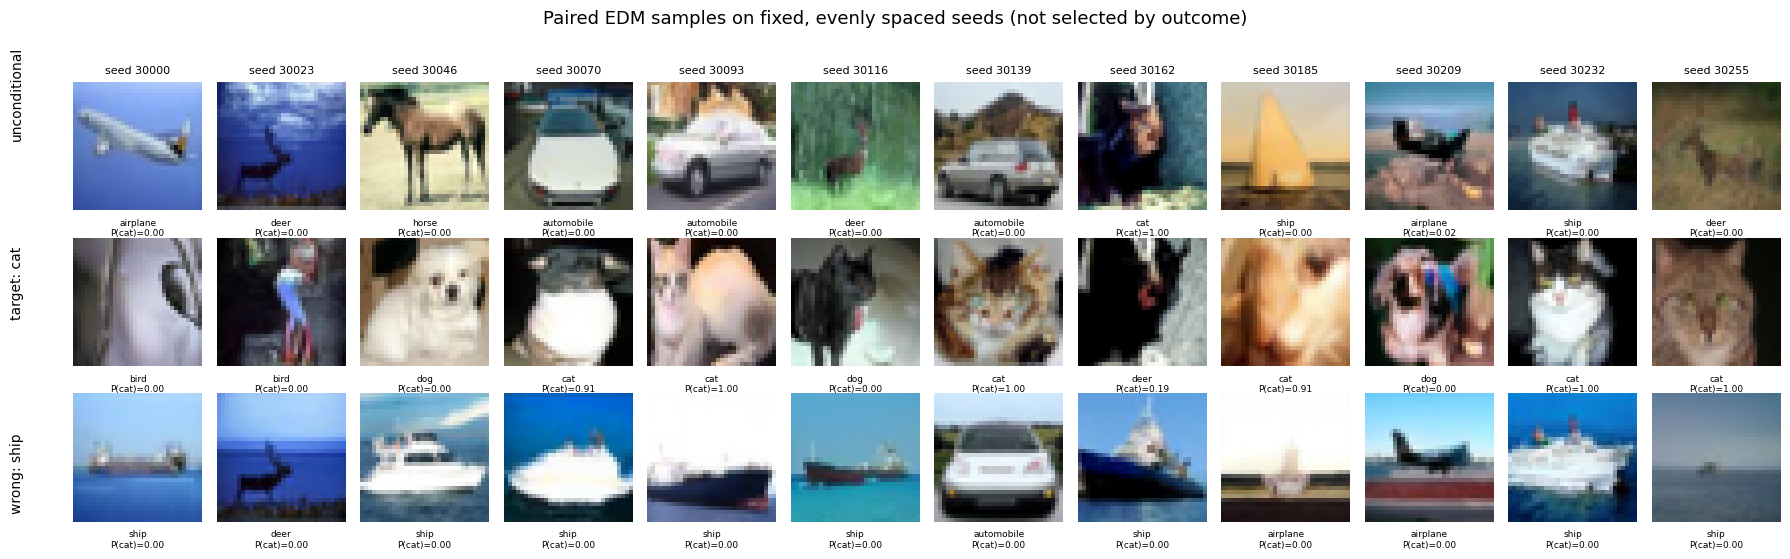

In [5]:
plot_method_grid(result, count=12)
plt.show()


## 4. Probe the denoiser along time

These panels show the network's current clean-image estimate for one trajectory
that changes from a non-cat baseline prediction to a cat prediction under the
target correction. It is selected transparently as the first such seed only to
make the mechanism visible; the fixed grid and aggregate metrics, not this
example, evaluate the method. Early estimates are uncertain and coarse; later
estimates become recognizable. After the declared window, the same
unconditional network continues both trajectories.


illustrative trajectory seed: 30006


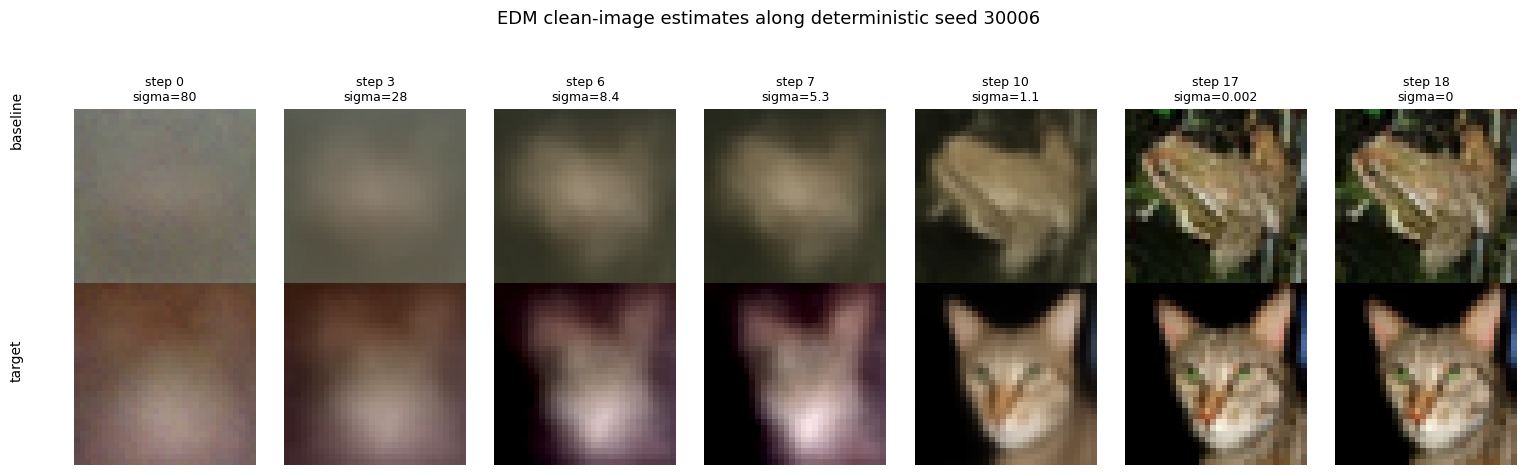

In [6]:
trajectory_index = first_target_conversion_index(result)
print("illustrative trajectory seed:", result["seeds"][trajectory_index])
plot_denoised_trajectory(result, sample_index=trajectory_index)
plt.show()


## 5. Evaluate control and side effects

A frozen ResNet-56 reports predicted labels, target probabilities, and
penultimate-layer features. The metrics deliberately include more than target
rate:

- distance from generated features to real target-class features;
- generated feature-covariance trace relative to baseline;
- class-histogram entropy and near-duplicate rate;
- paired target-rate uncertainty, runtime, and memory.

The evaluator is diagnostic evidence, not a proof that every steered image is a
valid member of the requested class.


In [7]:
metric_rows = []
for method in ["baseline", "zero", "target", "wrong"]:
    values = result["metrics"][method]
    metric_rows.append({
        "method": method,
        "target rate": values["target_rate"],
        "target probability": values["target_probability"],
        "target feature distance": values["target_feature_mean_distance"],
        "feature trace": values["feature_covariance_trace"],
        "class entropy": values["class_histogram_entropy"],
        "near duplicates": values["near_duplicate_rate"],
        "seconds": values["runtime_seconds"],
    })
metrics_table = pd.DataFrame(metric_rows).set_index("method")
metrics_table.round(4)


,target rate,target probability,target feature distance,feature trace,class entropy,near duplicates,seconds
method,,,,,,,
baseline,0.0664,0.0604,5.2286,34.5819,0.9909,0.0,20.0326
zero,0.0664,0.0604,5.2286,34.5819,0.9909,0.0,14.3437
target,0.4180,0.4176,2.8393,24.5344,0.7124,0.0,14.6529
wrong,0.0000,0.0000,7.8617,14.5070,0.3352,0.0,14.8080


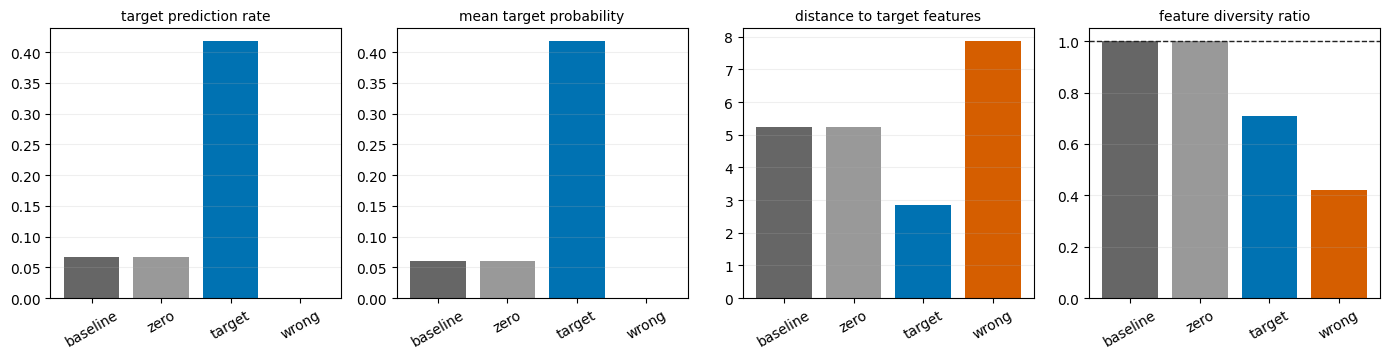

In [8]:
plot_metric_comparison(result)
plt.show()


## 6. Locked evaluation checks

After calibration, the revised thresholds and new evaluation seeds were locked.
The protocol passes only if every check below passes. In particular, the cat
rate must reach 40%, improve by at least 25 percentage points, have a positive
paired bootstrap lower bound, and preserve at least 60% of baseline feature
covariance. The wrong-class correction must not explain the cat gain. Passing
these checks supports a measurable but still partial steering result; it does
not mean every image is visibly a cat.


In [9]:
checks_table = pd.DataFrame(
    [{"check": name.replace("_", " "), "passed": passed} for name, passed in result["checks"].items()]
).set_index("check")
display(checks_table)
print("target-rate gain:", f"{result['target_rate_gain']:+.3f}")
print("paired gain 95% interval:", [round(value, 3) for value in result["paired_target_rate_gain_95ci"]])
print("wrong-class target-rate gain:", f"{result['wrong_class_target_rate_gain']:+.3f}")
print("zero-strength endpoint max |difference|:", f"{result['zero_endpoint_max_abs']:.3e}")
print("deterministic repeat max |difference|:", f"{result['deterministic_repeat_max_abs']:.3e}")
print("CIFAR-10 EDM protocol verdict:", result["release_status"])
interpretation = (
    "partial class steering, not reliable class-conditional generation"
    if result["release_status"] == "PASS"
    else "negative result under the locked protocol"
)
print("scientific interpretation:", interpretation)


,passed
check,
evaluator accuracy,True
all outputs finite,True
deterministic repeat,True
zero strength identity,True
absolute target rate,True
target rate gain,True
paired gain lower bound positive,True
target feature distance improves,True
feature diversity preserved,True


target-rate gain: +0.352
paired gain 95% interval: [0.285, 0.418]
wrong-class target-rate gain: -0.066
zero-strength endpoint max |difference|: 0.000e+00
deterministic repeat max |difference|: 0.000e+00
CIFAR-10 EDM protocol verdict: PASS
scientific interpretation: partial class steering, not reliable class-conditional generation


## What this notebook establishes

If the checks pass, the narrow conclusion is that an early, distribution-level
PCA denoiser correction provides measurable but incomplete class steering for
this fixed unconditional EDM model under paired controls. Inspect the images as
well as the classifier summaries: some paired trajectories convert clearly,
some remain ambiguous, and some do not become cats. It does **not** establish
that PCA guidance is optimal, that the classifier captures human judgment, or
that the same settings transfer to other datasets.

This bridge demonstrates noise alignment. Activation steering of a specific
EDM hidden block would require a separate hook definition, held-out activation
probe, matched shuffled direction, and its own evaluation.

**Sources**

- Karras et al., [*Elucidating the Design Space of Diffusion-Based Generative Models*](https://arxiv.org/abs/2206.00364).
- Li, Dai, and Qu, [*Understanding Generalizability of Diffusion Models Requires Rethinking the Hidden Gaussian Structure*](https://arxiv.org/abs/2410.24060).
- [Official NVIDIA EDM implementation](https://github.com/NVlabs/edm).
- [CIFAR pretrained evaluator source](https://github.com/chenyaofo/pytorch-cifar-models).
